# FreshBasket loyalty churn: data quality and exploratory analysis
**Goal of this notebook:** understand the three tables, log and fix every data-quality problem, and establish *how churn actually behaves* before modelling.
Run from the project root (`jupyter nbconvert --execute notebooks/01_data_quality_and_eda.ipynb`).

In [1]:
import sys, warnings; sys.path.insert(0, '..'); warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
from src import config as C, data as D, features as F
pd.set_option('display.width', 200, 'display.max_columns', 30, 'display.max_colwidth', 110)
prof_raw, act_raw, lab_raw = D.load_raw()
print({'profile': prof_raw.shape, 'activity': act_raw.shape, 'label': lab_raw.shape})
prof_raw.head(3)

{'profile': (2608, 10), 'activity': (28073, 12), 'label': (2605, 6)}


,CUSTOMER_ID,SIGNUP_DATE,AGE,GENDER,CITY,MEMBERSHIP_TIER,MARKETING_OPT_IN,PREFERRED_STORE_ID,PREFERRED_CATEGORY,HOME_STORE_PRICE_TIER
0,500001,2022-08-17,36.0,F,Madison,Silver,1,140,Frozen Foods,Value
1,500002,2023-06-24,37.0,F,Spokane,Silver,0,119,Beverages,Mainstream
2,500003,2021-03-31,53.0,NaN,Tulsa,Gold,0,119,Frozen Foods,Mainstream


## 1. Data quality: what was wrong and what we did
The workbook has a title banner above the real header (`header=1`). Issues below match the glossary's warning (duplicates, casing, missing values, negative spend, outliers) plus two found during exploration: *sign-flipped duplicate rows* and *missing customer-months*.

In [2]:
prof, act, lab, dq = D.clean(prof_raw, act_raw, lab_raw)
dq

,table,issue,rows_affected,action
0,profile,exact duplicate rows,8,dropped
1,profile,duplicate CUSTOMER_ID after exact-dup removal,0,none left
2,profile,inconsistent casing/whitespace in CITY,104,strip + title-case
3,profile,inconsistent casing/whitespace in MEMBERSHIP_TIER,104,strip + title-case
4,profile,missing AGE,78,median impute + missing flag (in features)
5,profile,missing GENDER,52,label 'Unknown'
6,profile,missing HOME_STORE_PRICE_TIER,130,label 'Unknown'
7,label,exact duplicate rows,5,dropped
8,label,missing LAST_PURCHASE_DATE,120,kept (no purchase in window)
9,activity,exact duplicate rows,58,dropped


**Notes on judgement calls**
- **Conflicting duplicates (2 rows):** the same customer-month appears twice, once with the spend sign flipped. Kept the non-negative row.
- **Negative spend (22 rows):** after de-duplication, remaining negatives are sign errors on months with purchases (`abs`) or zero-purchase months (set to 0).
- **Outliers:** one customer-month showed $3,731 against a 99.9th percentile of about $685; winsorised rather than dropped.
- **Missing customer-months (11,013):** see next section, this one matters for modelling.

## 2. Missing customer-months are a lapse signal, not random gaps

MONTH
2023-01-01     141
2023-02-01     201
2023-03-01     224
2023-04-01     297
2023-05-01     359
2023-06-01     413
2023-07-01     483
2023-08-01     526
2023-09-01     580
2023-10-01     642
2023-11-01     695
2023-12-01     771
2024-01-01     825
2024-02-01     892
2024-03-01     925
2024-04-01     993
2024-05-01    1000
2024-06-01    1046


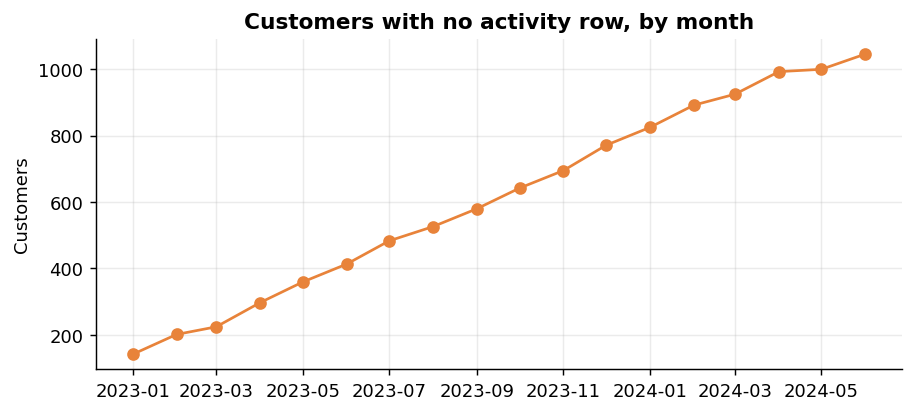

In [3]:
panel = D.build_panel(prof, act)
m = panel.groupby('MONTH').row_present.apply(lambda x: (x == 0).sum())
print(m.to_string())
display(Image('../outputs/figures/02_missing_rows.png'))

The count of customers with no row grows almost monotonically (about 140 in Jan-23 to about 1,050 by Jun-24). Rows effectively stop appearing as members lapse, so a missing month is **evidence of no activity**, not unknown data. We therefore treat it as zero activity (and keep a `missing_rows_l6` feature). Imputing means or dropping those months would have hidden exactly the behaviour we want to predict.

## 3. Distributions and outliers (after cleaning)

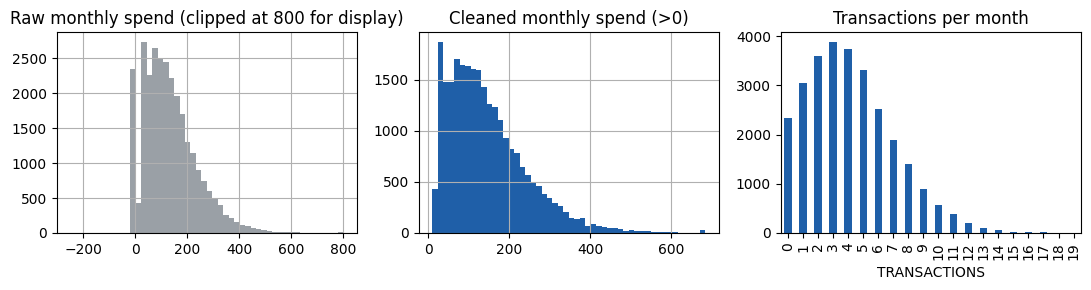

,TRANSACTIONS,TOTAL_SPEND,AVG_BASKET_VALUE,APP_SESSIONS,EMAILS_OPENED,COUPONS_REDEEMED,SUPPORT_TICKETS
count,28013.00,28013.00,28013.00,28013.00,28013.00,28013.00,28013.00
mean,4.17,134.35,29.64,2.05,1.02,0.56,0.16
std,2.90,101.98,12.05,1.77,1.16,0.76,0.41
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,58.91,24.66,1.00,0.00,0.00,0.00
50%,4.00,116.42,30.77,2.00,1.00,0.00,0.00
75%,6.00,188.25,37.00,3.00,2.00,1.00,0.00
max,19.00,685.07,68.10,13.00,9.00,8.00,4.00


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
act_raw.TOTAL_SPEND.clip(upper=800).hist(ax=ax[0], bins=50, color='#9aa0a6'); ax[0].set_title('Raw monthly spend (clipped at 800 for display)')
act.TOTAL_SPEND[act.TOTAL_SPEND > 0].hist(ax=ax[1], bins=50, color='#1f5fa8'); ax[1].set_title('Cleaned monthly spend (>0)')
act.TRANSACTIONS.value_counts().sort_index().plot.bar(ax=ax[2], color='#1f5fa8'); ax[2].set_title('Transactions per month')
plt.tight_layout(); plt.show()
act[['TRANSACTIONS','TOTAL_SPEND','AVG_BASKET_VALUE','APP_SESSIONS','EMAILS_OPENED','COUPONS_REDEEMED','SUPPORT_TICKETS']].describe().round(2)

## 4. The churn label: structure and a critical finding

{0: 0.685, 1: 0.315} <- overall churn rate (all 2,600 members)


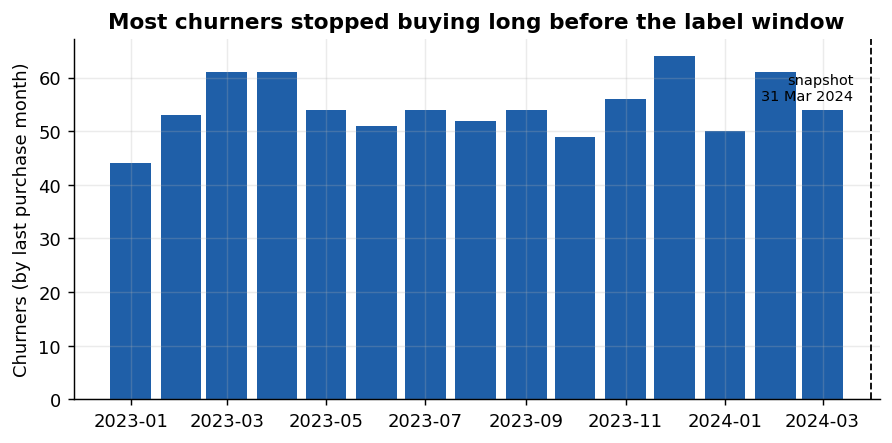

eligible members at 31-Mar-2024 (signed up and had bought before): 2368
churn                        churned  stayed   All
active_at_snapshot                                
bought in Jan-Mar 2024           164    1551  1715
no purchase in Jan-Mar 2024      649       4   653
All                              813    1555  2368
label rebuilt from raw activity == official CHURNED: 0.9983


In [5]:
print(lab.CHURNED.value_counts(normalize=True).round(3).to_dict(), '<- overall churn rate (all 2,600 members)')
display(Image('../outputs/figures/01_last_purchase_of_churners.png'))
snaps = F.build_all(panel, prof, lab)
t = snaps[C.TEST_ORIGIN]; e = t[t.eligible == 1]
print('eligible members at 31-Mar-2024 (signed up and had bought before):', len(e))
print(pd.crosstab(e.active_at_snapshot.map({1: 'bought in Jan-Mar 2024', 0: 'no purchase in Jan-Mar 2024'}), e.churn.map({0: 'stayed', 1: 'churned'}), margins=True))
print('label rebuilt from raw activity == official CHURNED:', round((e.label_derived == e.churn).mean(), 4))

**Finding:** of 2,368 members who had purchased before April 2024, **653 had already stopped buying before the label window and 649 of them (99.4%) are labelled churned.** Only **164 of the 1,715 still-active members (9.6%)** churn. So ~80% of churn is members who had *already lapsed* and are caught by a one-line recency rule.

Consequences for the analysis: (1) headline AUC on all members would look near-perfect and mean little, so every result is reported **twice**: all eligible members and still-active members; (2) the commercially useful question, *who among today's active customers is about to leave*, is the harder 9.6% problem.

## 5. Churners fade before they leave

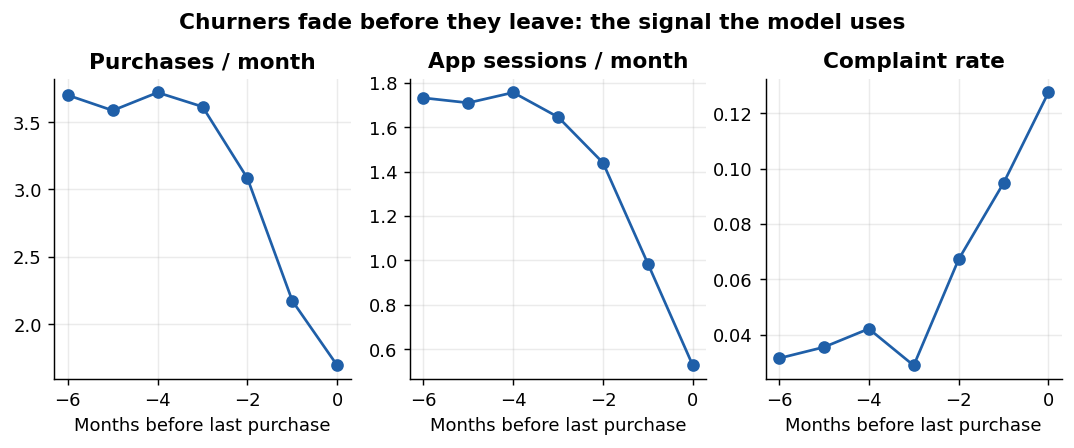

In [6]:
display(Image('../outputs/figures/03_pre_churn_decay.png'))

In the months before their last purchase, churners' purchases and app sessions fall steadily while complaints rise. That is the pre-churn signal the models learn from (and why trend features and engagement matter).

## 6. Who churns? Raw differences are mostly an exposure artefact

Churn by tier
                  mean  size
membership_tier             
Gold             0.330   751
Platinum         0.339   277
Silver           0.351  1340
Churn by tenure band: all members vs still-active only
               all  active_only
tenure_band                    
<6m          0.107        0.093
6-11m        0.317        0.113
12-23m       0.408        0.099
24m+         0.383        0.086


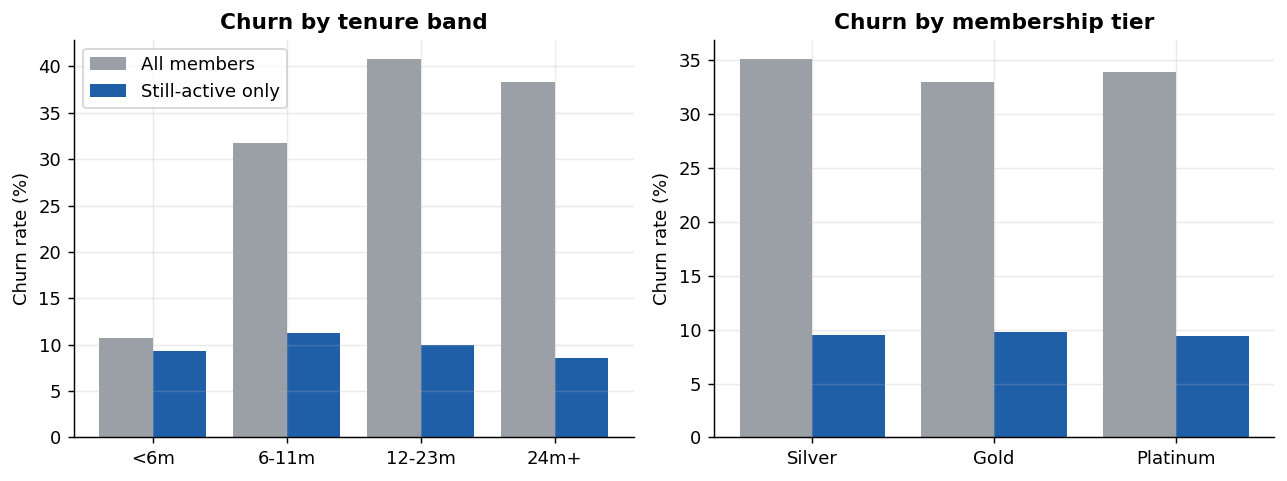

,dimension,chi2_p_all,chi2_p_active_only
0,membership_tier,0.6104,0.9833
1,signup_cohort,0.0000,0.1439
2,city,0.2192,0.9156
3,age_band,0.8008,0.4240
4,tenure_band,0.0000,0.6089
5,optin,0.0054,0.0618
6,home_price_tier,0.1174,0.6438
7,preferred_category,0.6909,0.2989


In [7]:
te = e
for dim in ['membership_tier', 'tenure_band']:
    pass
d = te.assign(tenure_band=pd.cut(te.tenure_months, [-1, 5, 11, 23, 100], labels=['<6m','6-11m','12-23m','24m+']))
print('Churn by tier'); print(d.groupby('membership_tier').churn.agg(['mean','size']).round(3))
print('Churn by tenure band: all members vs still-active only')
print(pd.DataFrame({'all': d.groupby('tenure_band').churn.mean(), 'active_only': d[d.active_at_snapshot==1].groupby('tenure_band').churn.mean()}).round(3))
display(Image('../outputs/figures/10_segments.png'))
pd.read_csv('../outputs/tables/segment_tests.csv').round(4)

Raw churn is much lower for new members (<6m: 10.7% vs ~40% for 12m+, p<0.001) **but among still-active members the gap disappears (p=0.61)**. Newer members simply have not had time to lapse. Membership tier, city, age band and preferred category show no meaningful difference either way. Marketing opt-out is higher-risk overall (37.8% vs 32.1%, p=0.005) but only marginal among active members (p=0.06).

## 7. Design decisions that follow from the EDA
| Issue | Decision |
|---|---|
| Only one official label window (Apr-Jun 2024) | Build **rolling snapshots** (Jun, Sep, Dec 2023 for training; Mar 2024 for test) using the same definition: no purchase in the next 3 months |
| Leakage risk | Every feature uses only months <= the snapshot; checked by wiping all later months and confirming features are unchanged |
| 80% of churn is already-lapsed | Report all-members **and** still-active metrics; compare against a recency rule |
| Same members appear in several snapshots | Add a customer-disjoint robustness check |
| Missing months = lapse | Zero-fill + `missing_rows_l6` feature |
| New signups after Mar-2024 / no purchase history | Not eligible at the snapshot (cannot have churned by definition) |